# Political Compass MCQ–chat comparison — primary models


    This notebook compares English MCQ configuration coordinates with English
    chat coordinates. It is a protocol comparison, not a test of one universal
    family or size effect. Displays follow the paper ordering rule.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'core.py').exists():
    candidate = Path('tasks/political-compass/analysis').resolve()
    if (candidate / 'core.py').exists():
        ANALYSIS_DIR = candidate
    else:
        candidate = Path.cwd().parent
        if (candidate / 'core.py').exists():
            ANALYSIS_DIR = candidate
        else:
            raise FileNotFoundError('Run this notebook from the repository or analysis directory.')
sys.path.insert(0, str(ANALYSIS_DIR))

from core import (
    GEMMA_MODELS, QWEN_MODELS, PRIMARY_MODELS, IDEOLOGY_ORDER,
    load_mcq_configurations, load_chat_configurations, plot_centroid_grid,
    qwen_think_outcomes, size_label,
)

sns.set_theme(style='whitegrid')

In [2]:
mcq = load_mcq_configurations()
mcq = mcq[mcq['language'].str.lower().eq('english')].rename(
    columns={'score_econ': 'economic', 'score_soc': 'social'}
)
chat = load_chat_configurations()
display(pd.DataFrame({
    'source': ['MCQ (English)', 'Chat (English)'],
    'configuration rows': [len(mcq), len(chat)],
    'models': [mcq['base_model'].nunique(), chat['base_model'].nunique()],
}))

,source,configuration rows,models
0,MCQ (English),3024,8
1,Chat (English),21600,8


## Family-grouped method order

The rows are Gemma MCQ, Gemma chat, Qwen MCQ, Qwen no-think chat, and
Qwen think chat. Within every row, checkpoint size increases from left
to right. Every marker is a persona centroid for that method/model.

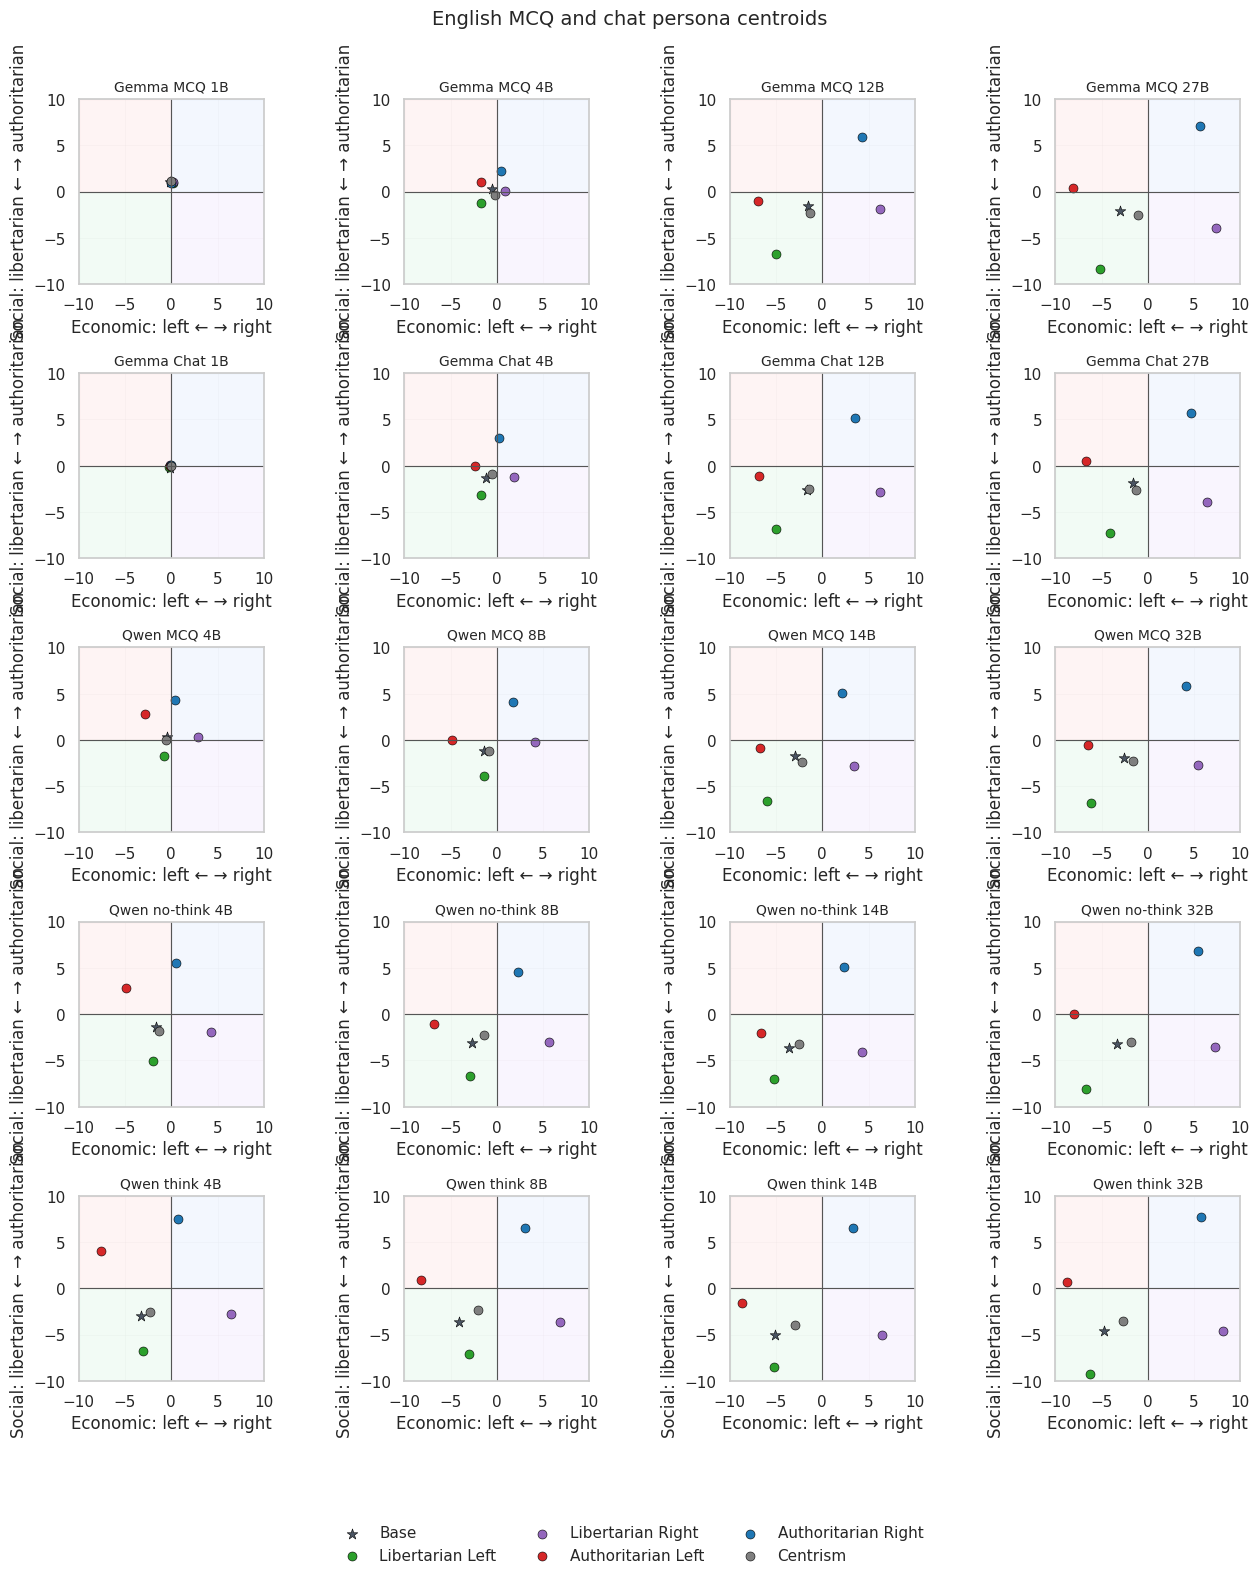

In [3]:
combined = pd.concat([
    mcq[['base_model', 'protocol', 'ideology', 'economic', 'social']],
    chat[['base_model', 'protocol', 'ideology', 'economic', 'social']],
], ignore_index=True)
panels = []
panels += [(f'{m}|mcq', f'Gemma MCQ {size_label(m)}') for m in GEMMA_MODELS]
panels += [(f'{m}|standard', f'Gemma Chat {size_label(m)}') for m in GEMMA_MODELS]
panels += [(f'{m}|mcq', f'Qwen MCQ {size_label(m)}') for m in QWEN_MODELS]
panels += [(f'{m}|no_think', f'Qwen no-think {size_label(m)}') for m in QWEN_MODELS]
panels += [(f'{m}|think', f'Qwen think {size_label(m)}') for m in QWEN_MODELS]
fig = plot_centroid_grid(combined, panels, ncols=4, title='English MCQ and chat persona centroids')
plt.show()

## Centroid displacement table

The value below is the Euclidean distance between a persona's English
MCQ centroid and its chat centroid. It summarizes a protocol-specific
shift for that model/persona. A larger value does not identify why the
shift happened and is not, by itself, a quality score.

In [4]:
mcq_centroids = mcq.groupby(['base_model', 'ideology'])[['economic', 'social']].mean()
chat_centroids = chat.groupby(['base_model', 'protocol', 'ideology'])[['economic', 'social']].mean()
rows = []
for (model, protocol, ideology), point in chat_centroids.iterrows():
    if (model, ideology) not in mcq_centroids.index:
        continue
    ref = mcq_centroids.loc[(model, ideology)]
    rows.append({
        'model': model, 'protocol': protocol, 'ideology': ideology,
        'MCQ–chat centroid distance': float(np.linalg.norm(point.to_numpy() - ref.to_numpy())),
    })
distance = pd.DataFrame(rows)
display(distance.pivot_table(index=['model', 'protocol'], columns='ideology', values='MCQ–chat centroid distance').round(2))

ideology                 authoritarian_left  authoritarian_right  base  \
model          protocol                                                  
Qwen3-14B      no_think                1.25                 0.23  1.99   
               think                   2.16                 1.88  3.94   
Qwen3-32B      no_think                1.55                 1.56  1.49   
               think                   2.59                 2.37  3.43   
Qwen3-4B       no_think                2.10                 1.14  2.06   
               think                   5.00                 3.15  4.25   
Qwen3-8B       no_think                2.23                 0.69  2.35   
               think                   3.55                 2.71  3.64   
gemma-3-12b-it standard                0.17                 1.04  1.03   
gemma-3-1b-it  standard                1.08                 0.92  1.30   
gemma-3-27b-it standard                1.46                 1.66  1.47   
gemma-3-4b-it  standard                1.24                 0.85  1.66   

ideology                 centrism  libertarian_left  libertarian_right  
model          protocol                                                 
Qwen3-14B      no_think      0.87              0.91               1.51  
               think         1.74              2.01               3.75  
Qwen3-32B      no_think      0.79              1.39               2.03  
               think         1.75              2.36               3.32  
Qwen3-4B       no_think      2.00              3.53               2.72  
               think         3.09              5.45               4.70  
Qwen3-8B       no_think      1.21              3.21               3.13  
               think         1.72              3.62               4.39  
gemma-3-12b-it standard      0.27              0.03               1.00  
gemma-3-1b-it  standard      1.15              1.16               0.93  
gemma-3-27b-it standard      0.32              1.51               0.92  
gemma-3-4b-it  standard      0.61              2.02               1.62